# # 02 - Sentiment & Emotion Profiling
 **Project:** AI-Based Media Empathy Analyzer  
 **Objective:** Augment the extracted screenplay dialogues with sentiment scores and specific emotional profiles to begin measuring character hostility, warmth, and neurodivergent communication contexts.


In [1]:
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# NLP Libraries
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import pipeline

# Register tqdm with pandas to use progress_apply
tqdm.pandas()

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Download required NLTK data (runs once)
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    print("Downloading VADER lexicon...")
    nltk.download('vader_lexicon', quiet=True)

# ## 2. Configuration

In [2]:
# Define base directory using a raw string for Windows path compatibility
BASE_DIR = Path(r"D:\project\NLP")

# Input and Output paths
PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
INPUT_FILE = PROCESSED_DATA_DIR / "dialogues.csv"
OUTPUT_FILE = PROCESSED_DATA_DIR / "dialogues_with_emotion.csv"

# Model Configuration
# We use a lightweight DistilRoBERTa model fine-tuned on Ekman's 6 basic emotions + neutral
EMOTION_MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"

# Ensure the processed directory exists (sanity check)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)


# ## 3. Loading Processed Data

In [3]:
print(f"Loading data from {INPUT_FILE}...")
if not INPUT_FILE.exists():
    raise FileNotFoundError(f"Cannot find {INPUT_FILE}. Please run Notebook 01 first.")

df = pd.read_csv(INPUT_FILE)

# Drop any accidental nulls that might have slipped through
df.dropna(subset=['Dialogue'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Loaded {len(df)} lines of dialogue.")
display(df.head(3))


Loading data from D:\project\NLP\data\processed\dialogues.csv...
Loaded 204 lines of dialogue.


,Movie,Scene,Character,Dialogue
0,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,BATEMAN V/O,...with goat cheese profiteroles and i also ha...
1,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,MCDERMOTT,you'll notice that my friends and i all look a...
2,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,MCDERMOTT,you think so? you'll look like you consciously...


# ## 4. Sentiment Analysis (VADER)
VADER is highly optimized for short, social-media-style texts and works exceptionally well on movie dialogue to gauge general polarity (Positive, Negative, Neutral).

In [4]:
print("Initializing VADER Sentiment Analyzer...")
sia = SentimentIntensityAnalyzer()

def get_vader_sentiment(text: str) -> dict:
    """
    Calculates VADER sentiment scores and classifies the overall polarity.
    
    Args:
        text (str): Cleaned dialogue string.
        
    Returns:
        dict: A dictionary containing the compound score and a discrete label.
    """
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    
    # Standard thresholding for VADER
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
        
    return {'Sentiment_Score': compound, 'Sentiment_Label': label}

print("Applying Sentiment Analysis...")
# Apply function and expand dictionary into separate DataFrame columns
sentiment_results = df['Dialogue'].progress_apply(get_vader_sentiment)
sentiment_df = pd.DataFrame(sentiment_results.tolist())

# Concatenate back to main dataframe
df = pd.concat([df, sentiment_df], axis=1)


Initializing VADER Sentiment Analyzer...
Applying Sentiment Analysis...


  0%|          | 0/204 [00:00<?, ?it/s]

# ## 5. Emotion Detection (HuggingFace Transformers)
 To evaluate empathy and hostility, simple sentiment isn't enough. We need to distinguish between *Fear* and *Anger* (both negative) or *Surprise* and *Joy* (both positive).


In [5]:
print(f"Loading Emotion Classifier: {EMOTION_MODEL_NAME}...")
# Device=0 attempts to use GPU if available, otherwise falls back to CPU (-1).
try:
    import torch
    device = 0 if torch.cuda.is_available() else -1
    print(f"Using device: {'GPU' if device == 0 else 'CPU'}")
except ImportError:
    device = -1
    print("PyTorch not found or CUDA unavailable. Using CPU.")

emotion_classifier = pipeline(
    "text-classification", 
    model=EMOTION_MODEL_NAME, 
    device=device,
    truncation=True, # Prevent crashes on overly long monologues
    max_length=512
)

def extract_emotion_batch(texts: list) -> list:
    """
    Extracts the dominant emotion from a list of texts using HuggingFace pipeline.
    
    Args:
        texts (list): A list of dialogue strings.
        
    Returns:
        list: A list of predicted emotion labels.
    """
    # Pipeline handles batching internally if passed a list
    results = emotion_classifier(texts)
    return [res['label'].capitalize() for res in results]

print("Applying Emotion Detection (this may take a few minutes depending on hardware)...")

# Convert dialogue column to list for pipeline processing
dialogue_list = df['Dialogue'].astype(str).tolist()

# Process in chunks to give tqdm a progress bar for large datasets
chunk_size = 500
emotion_labels = []

for i in tqdm(range(0, len(dialogue_list), chunk_size), desc="Classifying Emotions"):
    chunk = dialogue_list[i:i + chunk_size]
    emotions = extract_emotion_batch(chunk)
    emotion_labels.extend(emotions)

df['Emotion_Label'] = emotion_labels


Loading Emotion Classifier: j-hartmann/emotion-english-distilroberta-base...
Using device: CPU


Device set to use cpu


Applying Emotion Detection (this may take a few minutes depending on hardware)...


Classifying Emotions:   0%|          | 0/1 [00:00<?, ?it/s]

# ## 6. Saving the Enriched Dataset

Saving enriched dataset to D:\project\NLP\data\processed\dialogues_with_emotion.csv...
Save complete!


,Movie,Scene,Character,Dialogue,Sentiment_Score,Sentiment_Label,Emotion_Label
0,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,BATEMAN V/O,...with goat cheese profiteroles and i also ha...,0.6868,Positive,Neutral
1,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,MCDERMOTT,you'll notice that my friends and i all look a...,0.4644,Positive,Anger
2,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,MCDERMOTT,you think so? you'll look like you consciously...,0.7370,Positive,Sadness
3,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,MCDERMOTT,that s paul owen. that's not paul owen. paul o...,0.8496,Positive,Surprise
4,AMERICAN_PSYCHO,INT. 'PASTELS' RESTAURANT - NIGHT,VAN PATTEN,"you spin a dreidel, mcdermott, not a menorah. ...",0.8594,Positive,Neutral
5,AMERICAN_PSYCHO,INT. LIMOUSINE - NIGHT,VAN PATTEN,last week i picked up this vassar chick,0.0000,Neutral,Joy
6,AMERICAN_PSYCHO,INT. LIMOUSINE - NIGHT,MCDERMOTT,but i never told you what happened afterwards....,0.1647,Positive,Disgust
7,AMERICAN_PSYCHO,INT. LIMOUSINE - NIGHT,IN UNISON,never date a vassar girl.,0.0000,Neutral,Disgust
8,AMERICAN_PSYCHO,EXT. 'TUNNEL'NIGHTCLUB - NIGHT,PRICE,"i suppose he doesn't want the car. price, ask ...",0.3565,Positive,Surprise
9,AMERICAN_PSYCHO,"INT. LADIES ROOM,TUNNEL - NIGHT",PRICE,"i'm not sure, guy, but i don't think dyslexia ...",-0.6899,Negative,Surprise


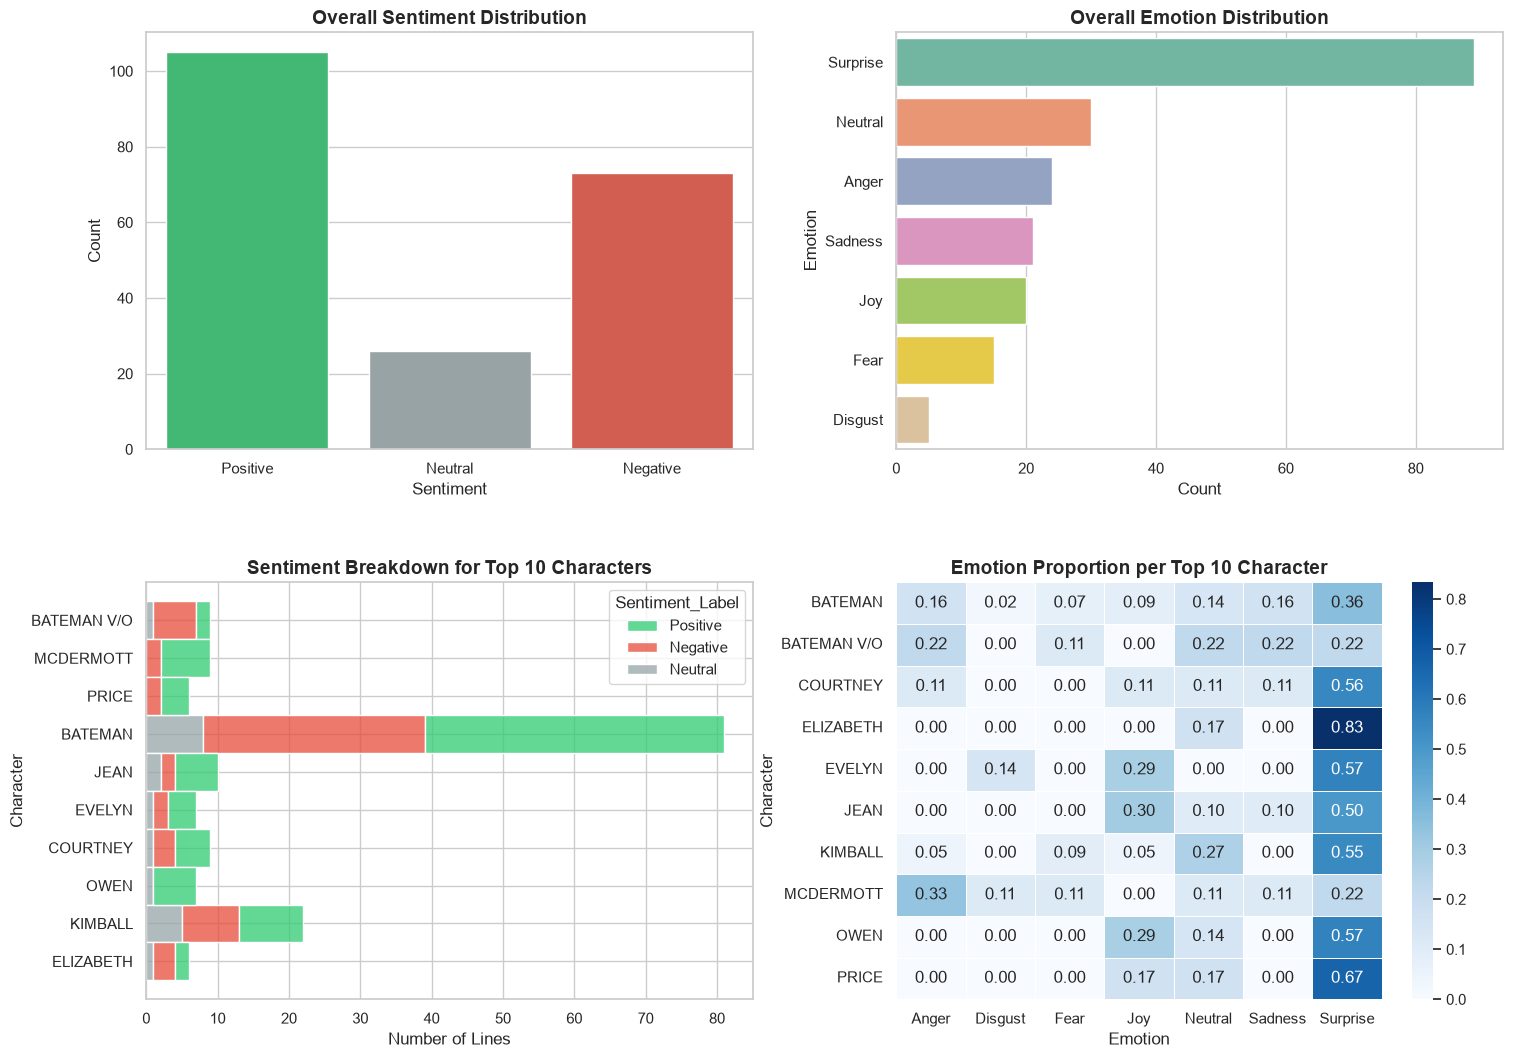

EMPATHY & HOSTILITY PREVIEW
Characters with Highest Hostility (Anger/Disgust) Rate:
 - BATEMAN              18.5% of lines
 - KIMBALL              4.5% of lines
------------------------------------------------------------
Characters with Highest Calm/Positive (Joy/Neutral) Rate:
 - KIMBALL              31.8% of lines
 - BATEMAN              22.2% of lines


In [6]:
print(f"Saving enriched dataset to {OUTPUT_FILE}...")
df.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
print("Save complete!")

# Display the resulting dataframe structure
display(df.head(10))

# %% [markdown]
# ## 7. Exploratory Data Analysis (EDA)
# Let's visualize the emotional landscape of our screenplay corpus.

# %%
# Set standard plotting aesthetic
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.tight_layout(pad=6.0)

# 1. Overall Sentiment Distribution
sns.countplot(
    data=df, 
    x='Sentiment_Label', 
    palette={'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'},
    order=['Positive', 'Neutral', 'Negative'],
    ax=axes[0, 0]
)
axes[0, 0].set_title('Overall Sentiment Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Sentiment')
axes[0, 0].set_ylabel('Count')

# 2. Overall Emotion Distribution
sns.countplot(
    data=df, 
    y='Emotion_Label', 
    palette='Set2',
    order=df['Emotion_Label'].value_counts().index,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Overall Emotion Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('Emotion')

# 3. Sentiment by Top 10 Characters
top_10_chars = df['Character'].value_counts().head(10).index
top_chars_df = df[df['Character'].isin(top_10_chars)]

sns.histplot(
    data=top_chars_df, 
    y='Character', 
    hue='Sentiment_Label', 
    multiple="stack", 
    palette={'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'},
    ax=axes[1, 0]
)
axes[1, 0].set_title('Sentiment Breakdown for Top 10 Characters', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Number of Lines')
axes[1, 0].set_ylabel('Character')

# 4. Emotion Heatmap for Top 10 Characters
# Create a cross-tabulation of Characters and Emotions
char_emotion_ct = pd.crosstab(top_chars_df['Character'], top_chars_df['Emotion_Label'], normalize='index')

sns.heatmap(
    char_emotion_ct, 
    cmap='Blues', 
    annot=True, 
    fmt=".2f", 
    linewidths=.5,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Emotion Proportion per Top 10 Character', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Emotion')
axes[1, 1].set_ylabel('Character')

plt.show()

# %% [markdown]
# ## 8. Empathy Insights Preview
# Quickly identifying highly negative or hostile character arcs.

# %%
print("="*60)
print("EMPATHY & HOSTILITY PREVIEW")
print("="*60)

# Find characters with the highest percentage of 'Anger' or 'Disgust' lines (minimum 20 lines spoken)
char_counts = df['Character'].value_counts()
valid_chars = char_counts[char_counts >= 20].index

if len(valid_chars) > 0:
    hostility_df = top_chars_df[top_chars_df['Character'].isin(valid_chars)]
    hostility_rates = hostility_df.groupby('Character')['Emotion_Label'].apply(
        lambda x: (x.isin(['Anger', 'Disgust']).sum() / len(x)) * 100
    ).sort_values(ascending=False).head(5)
    
    print("Characters with Highest Hostility (Anger/Disgust) Rate:")
    for char, rate in hostility_rates.items():
        print(f" - {char:<20} {rate:.1f}% of lines")
    
    print("-" * 60)
    
    empathy_rates = hostility_df.groupby('Character')['Emotion_Label'].apply(
        lambda x: (x.isin(['Joy', 'Neutral']).sum() / len(x)) * 100
    ).sort_values(ascending=False).head(5)
    
    print("Characters with Highest Calm/Positive (Joy/Neutral) Rate:")
    for char, rate in empathy_rates.items():
        print(f" - {char:<20} {rate:.1f}% of lines")
else:
    print("Not enough data to calculate per-character insights.")
    
print("="*60)